# NLP Disaster Tweets — DistilBERT Fine-tuning

Бинарная классификация твитов: реальная катастрофа (`target=1`) или нет (`target=0`).  
Метрика: **F1-score**.

Подход: fine-tuning предобученной модели `distilbert-base-uncased` через HuggingFace Transformers + PyTorch.

## 1. Импорты и настройки

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    NUM_GPUS = 1
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    NUM_GPUS = torch.cuda.device_count()
else:
    DEVICE = torch.device('cpu')
    NUM_GPUS = 0

NUM_WORKERS = 4 if DEVICE.type == 'cuda' else 0
PIN_MEMORY  = DEVICE.type == 'cuda'

print(f'Device: {DEVICE}')
print(f'GPUs available: {NUM_GPUS}')
if DEVICE.type == 'cuda':
    for i in range(NUM_GPUS):
        props = torch.cuda.get_device_properties(i)
        print(f'  GPU {i}: {props.name} ({props.total_memory // 1024**3} GB)')
print(f'PyTorch: {torch.__version__}')

## 2. Загрузка данных

In [2]:
df_train = pd.read_csv('data/train.csv')
df_test  = pd.read_csv('data/test.csv')

print(f'Train: {df_train.shape},  Test: {df_test.shape}')
df_train.head()

Train: (7613, 5),  Test: (3263, 4)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [3]:
print('Пропуски в train:')
print(df_train.isnull().sum())
print('\nРаспределение классов:')
print(df_train['target'].value_counts())

Пропуски в train:
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

Распределение классов:
target
0    4342
1    3271
Name: count, dtype: int64


## 3. EDA

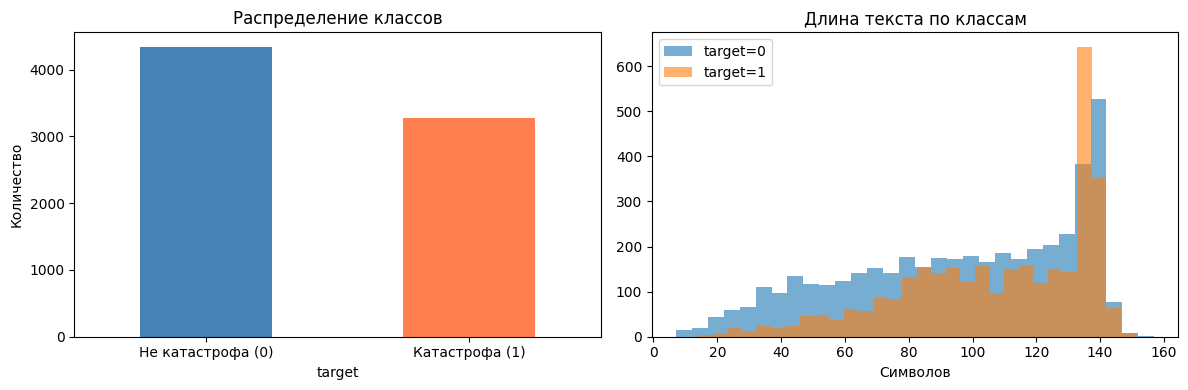

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_train['target'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Распределение классов')
axes[0].set_xticklabels(['Не катастрофа (0)', 'Катастрофа (1)'], rotation=0)
axes[0].set_ylabel('Количество')

df_train['text_len'] = df_train['text'].str.len()
for label, group in df_train.groupby('target'):
    axes[1].hist(group['text_len'], alpha=0.6, bins=30, label=f'target={label}')
axes[1].set_title('Длина текста по классам')
axes[1].set_xlabel('Символов')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Очистка текста

In [5]:
def clean_text(text: str) -> str:
    text = re.sub(r'http\S+|www\S+', '', text)      # URL
    text = re.sub(r'<.*?>', '', text)                 # HTML-теги
    text = re.sub(r'@\w+', '', text)                  # @mentions
    text = re.sub(r'#(\w+)', r'\1', text)             # хэштеги: убираем #, слово оставляем
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)       # не-ASCII (emoji и пр.)
    text = re.sub(r'[^\w\s.,!?\'-]', ' ', text)      # спецсимволы
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_train['clean_text'] = df_train['text'].apply(clean_text)
df_test['clean_text']  = df_test['text'].apply(clean_text)

for orig, clean in zip(df_train['text'][:3], df_train['clean_text'][:3]):
    print('ORIG :', orig)
    print('CLEAN:', clean)
    print()

ORIG : Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
CLEAN: Our Deeds are the Reason of this earthquake May ALLAH Forgive us all

ORIG : Forest fire near La Ronge Sask. Canada
CLEAN: Forest fire near La Ronge Sask. Canada

ORIG : All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected
CLEAN: All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected



## 5. Токенизация и Dataset

In [6]:
MODEL_NAME    = 'distilbert-base-uncased'
MAX_LEN       = 128
EPOCHS        = 3
LEARNING_RATE = 2e-5

# Базовый batch size на одну GPU (или CPU/MPS); масштабируется на число GPU
BATCH_SIZE_PER_DEVICE = 32
BATCH_SIZE = BATCH_SIZE_PER_DEVICE * max(NUM_GPUS, 1)

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
print(f'Tokenizer loaded | batch size: {BATCH_SIZE} ({BATCH_SIZE_PER_DEVICE} × {max(NUM_GPUS, 1)} GPU(s))')

Tokenizer loaded | batch size: 128 (32 × 4 GPU(s))


In [7]:
class TweetDataset(Dataset):
    def __init__(self, texts, labels=None):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding=True,
            max_length=MAX_LEN,
            return_tensors='pt'
        )
        self.labels = labels

    def __len__(self):
        return self.encodings['input_ids'].shape[0]

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels.iloc[idx], dtype=torch.long)
        return item

In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    df_train['clean_text'], df_train['target'],
    test_size=0.15, random_state=SEED, stratify=df_train['target']
)

train_dataset = TweetDataset(X_train, y_train)
val_dataset   = TweetDataset(X_val, y_val)
test_dataset  = TweetDataset(df_test['clean_text'])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}')

Train: 6471, Val: 1142, Test: 3263


## 6. Модель и оптимизатор

In [9]:
model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model = model.to(DEVICE)

# DataParallel: автоматически распределяет батчи по всем доступным GPU
if NUM_GPUS > 1:
    model = nn.DataParallel(model)
    print(f'DataParallel enabled on {NUM_GPUS} GPUs')

# Для grad clipping и подсчёта параметров — обращаемся к базовой модели
base_model = model.module if isinstance(model, nn.DataParallel) else model

optimizer = torch.optim.AdamW(base_model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

total_steps  = EPOCHS * len(train_loader)
warmup_steps = total_steps // 10

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f'Parameters: {sum(p.numel() for p in base_model.parameters()):,}')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DataParallel enabled on 4 GPUs
Parameters: 66,955,010


## 7. Обучение

In [10]:
from tqdm.auto import tqdm

def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss = 0
    all_labels, all_preds = [], []

    base = model.module if isinstance(model, nn.DataParallel) else model

    progress = tqdm(loader, desc='Train', leave=False)
    for batch in progress:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        output = model(**batch)

        # DataParallel возвращает loss по каждой GPU — усредняем
        loss = output.loss.mean()

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(base.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        all_preds.extend(output.logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(batch['labels'].cpu().numpy())

        progress.set_postfix(loss=f'{loss.item():.4f}')

    return total_loss / len(loader), f1_score(all_labels, all_preds)


def eval_epoch(model, loader):
    model.eval()
    total_loss = 0
    all_labels, all_preds = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc='Val', leave=False):
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            output = model(**batch)
            total_loss += output.loss.mean().item()
            all_preds.extend(output.logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(batch['labels'].cpu().numpy())

    return total_loss / len(loader), f1_score(all_labels, all_preds)

In [11]:
history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
best_f1 = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_f1 = train_epoch(model, train_loader, optimizer, scheduler)
    val_loss, val_f1     = eval_epoch(model, val_loader)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)

    print(f'Epoch {epoch}/{EPOCHS} | '
          f'Train loss: {train_loss:.4f}, F1: {train_f1:.4f} | '
          f'Val loss: {val_loss:.4f}, F1: {val_f1:.4f}')

    if val_f1 > best_f1:
        best_f1 = val_f1
        # Сохраняем веса базовой модели (без обёртки DataParallel)
        state_dict = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
        torch.save(state_dict, 'best_model.pt')
        print(f'  → Saved best model (val F1={best_f1:.4f})')

print(f'\nBest val F1: {best_f1:.4f}')

Train:   0%|          | 0/51 [00:00<?, ?it/s]

/home/e.loshmanov/miniconda3/envs/kaggle/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Val:   0%|          | 0/9 [00:00<?, ?it/s]

/home/e.loshmanov/miniconda3/envs/kaggle/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch 1/3 | Train loss: 0.5501, F1: 0.6340 | Val loss: 0.4028, F1: 0.7950
  → Saved best model (val F1=0.7950)


...

Train:   0%|          | 0/51 [00:00<?, ?it/s]

/home/e.loshmanov/miniconda3/envs/kaggle/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Val:   0%|          | 0/9 [00:00<?, ?it/s]

/home/e.loshmanov/miniconda3/envs/kaggle/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch 3/3 | Train loss: 0.3432, F1: 0.8330 | Val loss: 0.3812, F1: 0.8141
  → Saved best model (val F1=0.8141)

Best val F1: 0.8141


## 8. Графики обучения

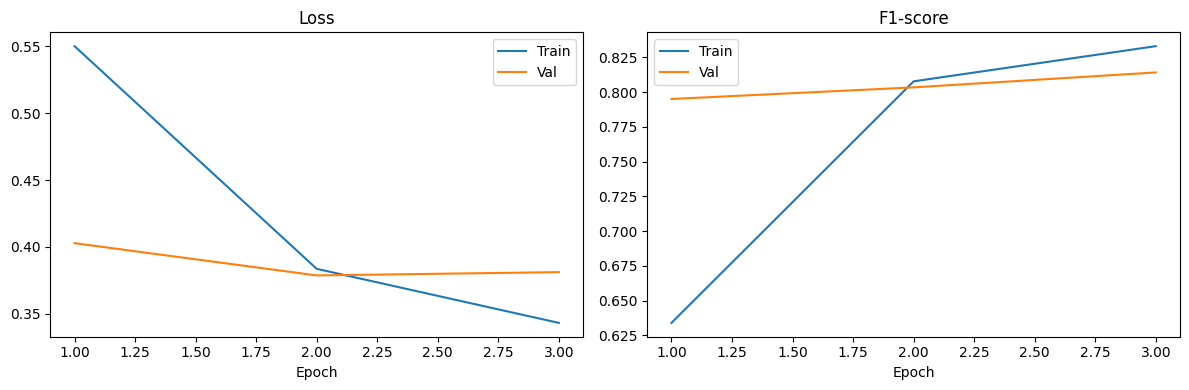

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, history['train_loss'], label='Train')
axes[0].plot(epochs_range, history['val_loss'],   label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs_range, history['train_f1'], label='Train')
axes[1].plot(epochs_range, history['val_f1'],   label='Val')
axes[1].set_title('F1-score')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Оценка лучшей модели на валидации

In [ ]:
base_model = model.module if isinstance(model, nn.DataParallel) else model
base_model.load_state_dict(torch.load('best_model.pt', map_location=DEVICE, weights_only=True))

model.eval()
all_labels, all_preds = [], []

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        output = model(**batch)
        all_preds.extend(output.logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(batch['labels'].cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=['Not Disaster', 'Disaster']))

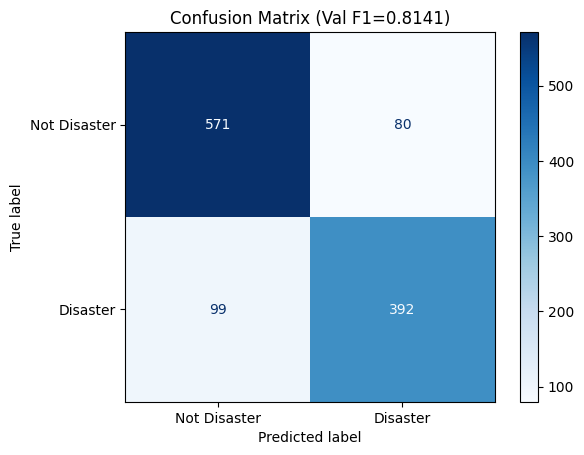

In [14]:
cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=['Not Disaster', 'Disaster']).plot(cmap='Blues')
plt.title(f'Confusion Matrix (Val F1={f1_score(all_labels, all_preds):.4f})')
plt.show()

## 10. Предсказания на тесте и submission

In [15]:
model.eval()
test_preds = []

with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        output = model(**batch)
        test_preds.extend(output.logits.argmax(dim=1).cpu().numpy())

print(f'Total predictions: {len(test_preds)}')
print(f'Disaster: {sum(test_preds)}, Not disaster: {len(test_preds) - sum(test_preds)}')

Total predictions: 3263
Disaster: 1297, Not disaster: 1966


## 10.1 Overlap Fix — перезапись предсказаний по известным меткам из train

In [ ]:
def majority_label(labels):
    counts = labels.value_counts()
    if len(counts) > 1 and counts.iloc[0] == counts.iloc[1]:
        return 1
    return counts.idxmax()

# Дедуплицируем train по raw text и строим словарь text → метка
train_dedup = df_train.groupby('text', sort=False)['target'].agg(majority_label)
overlap_labels = train_dedup[train_dedup.index.isin(df_test['text'])].to_dict()

# Перезаписываем предсказания для тест-твитов, которые встречались в train
overridden = 0
for i, text in enumerate(df_test['text']):
    if text in overlap_labels:
        test_preds[i] = overlap_labels[text]
        overridden += 1

print(f'Overlap fix: overridden {overridden} test predictions using known train labels')
print(f'Unique overlapping texts found: {len(overlap_labels)}')

In [ ]:
submission = pd.read_csv('data/sample_submission.csv')
submission['target'] = test_preds
submission.to_csv('submission3.csv', index=False)

print('submission3.csv saved')
submission.head()